# Notebook 01 — Exploración del Dataset

**Objetivo:** entender la distribución de los datos antes de aplicar modelos.  
**Input:** `datasets/processed/logs.csv`  
**Output:** visualizaciones y observaciones para el capítulo de análisis de la tesis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

DATA = Path('../datasets/processed/logs.csv')
FIG_DIR = Path('../docs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Carga y vista general

In [2]:
df = pd.read_csv(DATA)
df['timestamp_dt'] = pd.to_datetime(df['timestamp_dt'], utc=True, errors='coerce').dt.tz_convert(None)
print(f'Shape: {df.shape}')
print(f'Rango temporal: {df["timestamp_dt"].min()}  →  {df["timestamp_dt"].max()}')
df.head(3)

Shape: (3279, 46)
Rango temporal: 2026-05-06 23:28:29.806000  →  2026-05-07 00:19:21.148000


,timestamp_dt,log_type,message,@version,severity,host,log,input,source_type,ecs,...,event_type,ip,method,timestamp,hour,day_of_week,is_weekend,event_count_window,error_count_window,failed_login_count
0,2026-05-06 23:28:29.806,error,"2026/05/06 23:28:08 [emerg] 1#1: duplicate ""lo...",1.0,error,{'name': '148e72878c55'},"{'offset': 0, 'file': {'path': '/logs/nginx/er...",{'type': 'filestream'},nginx,{'version': '8.0.0'},...,NaN,NaN,NaN,NaN,23,2,0,1.0,0.0,0.0
1,2026-05-07 00:11:12.781,error,"2026/05/07 00:11:09 [emerg] 1#1: duplicate ""lo...",1.0,error,{'name': '148e72878c55'},"{'offset': 99, 'file': {'path': '/logs/nginx/e...",{'type': 'filestream'},nginx,{'version': '8.0.0'},...,NaN,NaN,NaN,NaN,0,3,0,1.0,0.0,0.0
2,NaT,access,192.168.65.1 - - [07/May/2026:00:12:00 +0000] ...,1.0,info,{'name': '148e72878c55'},"{'offset': 0, 'file': {'path': '/logs/nginx/ac...",{'type': 'filestream'},nginx,{'version': '8.0.0'},...,NaN,NaN,NaN,NaN,0,3,0,2.0,0.0,0.0


In [3]:
# Tipos y nulos
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2)
})
info[info['null_pct'] > 0].sort_values('null_pct', ascending=False)

,dtype,non_null,null_pct
http_version,float64,2,99.94
raw_timestamp,object,2,99.94
user,object,2,99.94
referrer,object,2,99.94
event_type,object,156,95.24
failed_reason,object,380,88.41
error_msg,object,399,87.83
app,object,453,86.18
source_host,object,453,86.18
request_method,object,455,86.12


## 2. Distribución de labels y escenarios

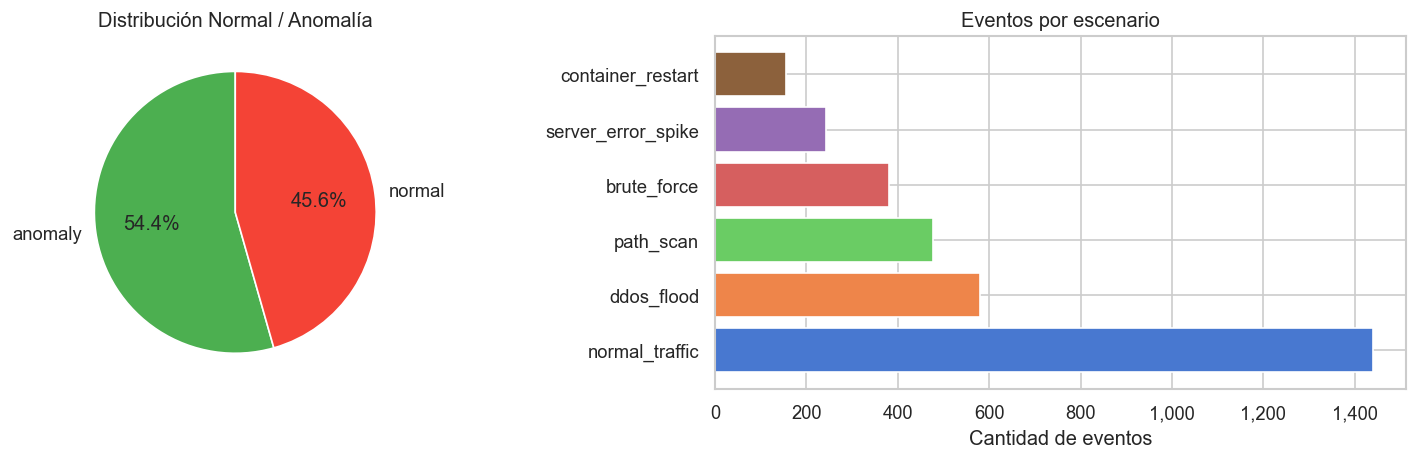

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Labels
if 'label' in df.columns:
    label_counts = df['label'].value_counts()
    axes[0].pie(
        label_counts,
        labels=label_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#4CAF50', '#F44336']
    )
    axes[0].set_title('Distribución Normal / Anomalía')

# Escenarios
if 'scenario' in df.columns:
    sc = df['scenario'].value_counts()
    axes[1].barh(sc.index, sc.values, color=sns.color_palette('muted', len(sc)))
    axes[1].set_xlabel('Cantidad de eventos')
    axes[1].set_title('Eventos por escenario')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'label_distribution.png', bbox_inches='tight')
plt.show()

## 3. Distribución de códigos HTTP

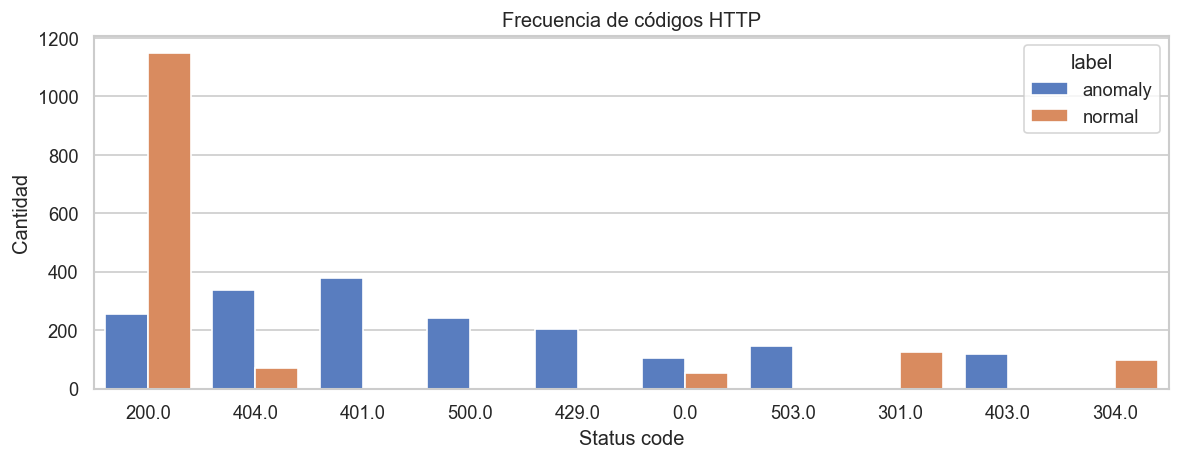


Top status codes:
status_code
200.0    1405
404.0     405
401.0     380
500.0     243
429.0     204
0.0       158
503.0     144
301.0     125
403.0     117
304.0      98
Name: count, dtype: int64


In [5]:
if 'status_code' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    order = df['status_code'].value_counts().index
    hue = df['label'] if 'label' in df.columns else None
    sns.countplot(data=df, x='status_code', order=order, hue=hue, ax=ax)
    ax.set_title('Frecuencia de códigos HTTP')
    ax.set_xlabel('Status code')
    ax.set_ylabel('Cantidad')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'status_codes.png', bbox_inches='tight')
    plt.show()

    print('\nTop status codes:')
    print(df['status_code'].value_counts().head(10))

## 4. Response time: normal vs anomalía

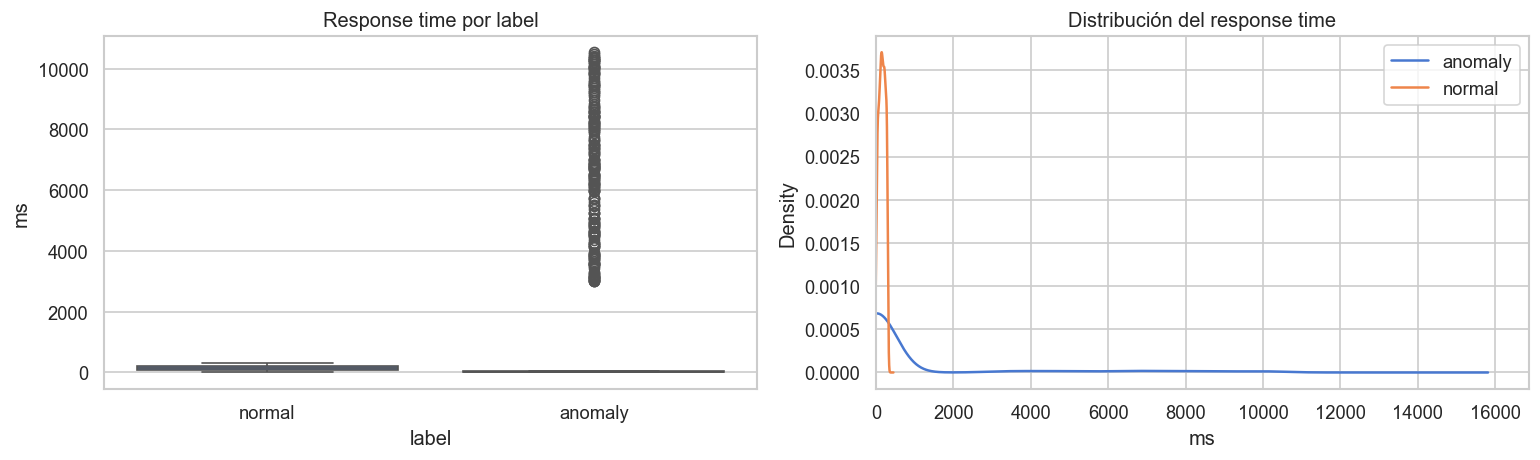

          count    mean     std  min   25%    50%    75%      max
label                                                            
anomaly  1782.0  1007.2  2665.8  0.0  11.0   21.0   40.0  11957.0
normal   1493.0   156.3    84.4  0.0  87.0  157.0  226.0    300.0


In [6]:
if 'response_time_ms' in df.columns and 'label' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Boxplot
    df_filtered = df[df['response_time_ms'] < df['response_time_ms'].quantile(0.99)]
    sns.boxplot(data=df_filtered, x='label', y='response_time_ms', ax=axes[0])
    axes[0].set_title('Response time por label')
    axes[0].set_ylabel('ms')

    # KDE
    for label, grp in df_filtered.groupby('label'):
        grp['response_time_ms'].plot.kde(ax=axes[1], label=label)
    axes[1].set_title('Distribución del response time')
    axes[1].set_xlabel('ms')
    axes[1].legend()
    axes[1].set_xlim(left=0)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'response_time.png', bbox_inches='tight')
    plt.show()

    print(df.groupby('label')['response_time_ms'].describe().round(1))

## 5. IPs más frecuentes

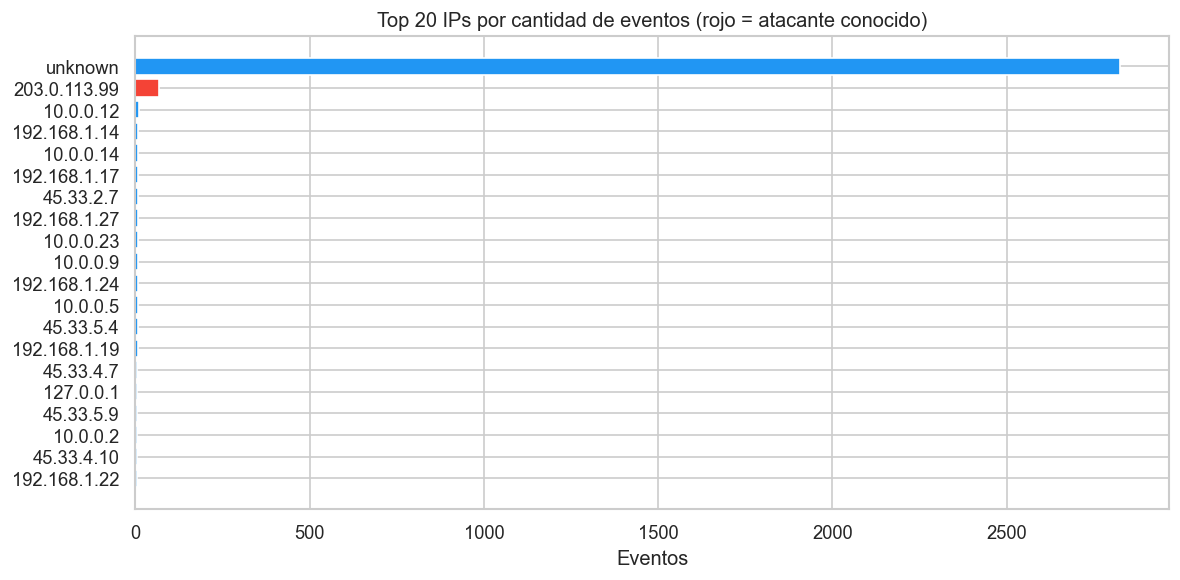

In [7]:
ip_col = 'ip_address' if 'ip_address' in df.columns else 'ip'
if ip_col in df.columns:
    top_ips = df[ip_col].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#F44336' if ip == '203.0.113.99' else '#2196F3' for ip in top_ips.index]
    ax.barh(top_ips.index[::-1], top_ips.values[::-1], color=colors[::-1])
    ax.set_title('Top 20 IPs por cantidad de eventos (rojo = atacante conocido)')
    ax.set_xlabel('Eventos')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'top_ips.png', bbox_inches='tight')
    plt.show()

## 6. Patrón temporal (eventos por hora)

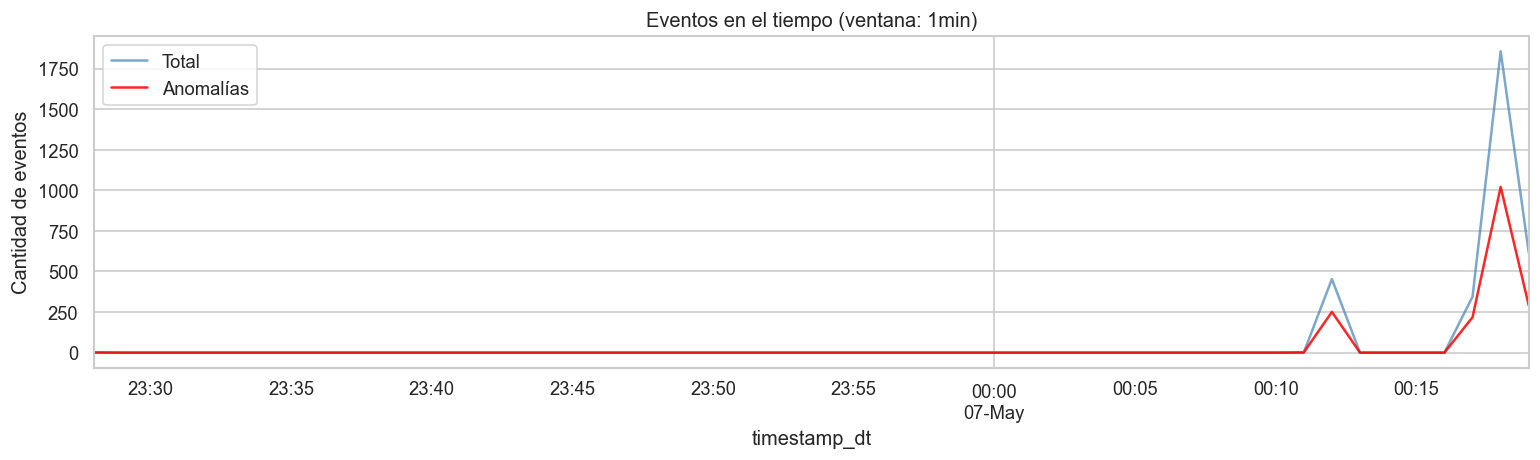

In [8]:
if 'timestamp_dt' in df.columns:
    df_time = df.copy()
    # Asegurar DatetimeIndex tz-naive para resample
    df_time['timestamp_dt'] = pd.to_datetime(df_time['timestamp_dt'], errors='coerce')
    if hasattr(df_time['timestamp_dt'].dt, 'tz') and df_time['timestamp_dt'].dt.tz is not None:
        df_time['timestamp_dt'] = df_time['timestamp_dt'].dt.tz_convert(None)
    df_time = df_time.dropna(subset=['timestamp_dt']).set_index('timestamp_dt').sort_index()

    fig, ax = plt.subplots(figsize=(13, 4))
    resample_rule = '1min' if len(df) < 50000 else '5min'

    total = df_time['status_code'].resample(resample_rule).count()
    total.plot(ax=ax, label='Total', color='steelblue', alpha=0.7)

    if 'label' in df.columns:
        anomalies = df_time[df_time['label'] != 'normal']['status_code'].resample(resample_rule).count()
        anomalies.plot(ax=ax, label='Anomalías', color='red', alpha=0.85)

    ax.set_title(f'Eventos en el tiempo (ventana: {resample_rule})')
    ax.set_ylabel('Cantidad de eventos')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'events_over_time.png', bbox_inches='tight')
    plt.show()

## 7. Correlación de features numéricas

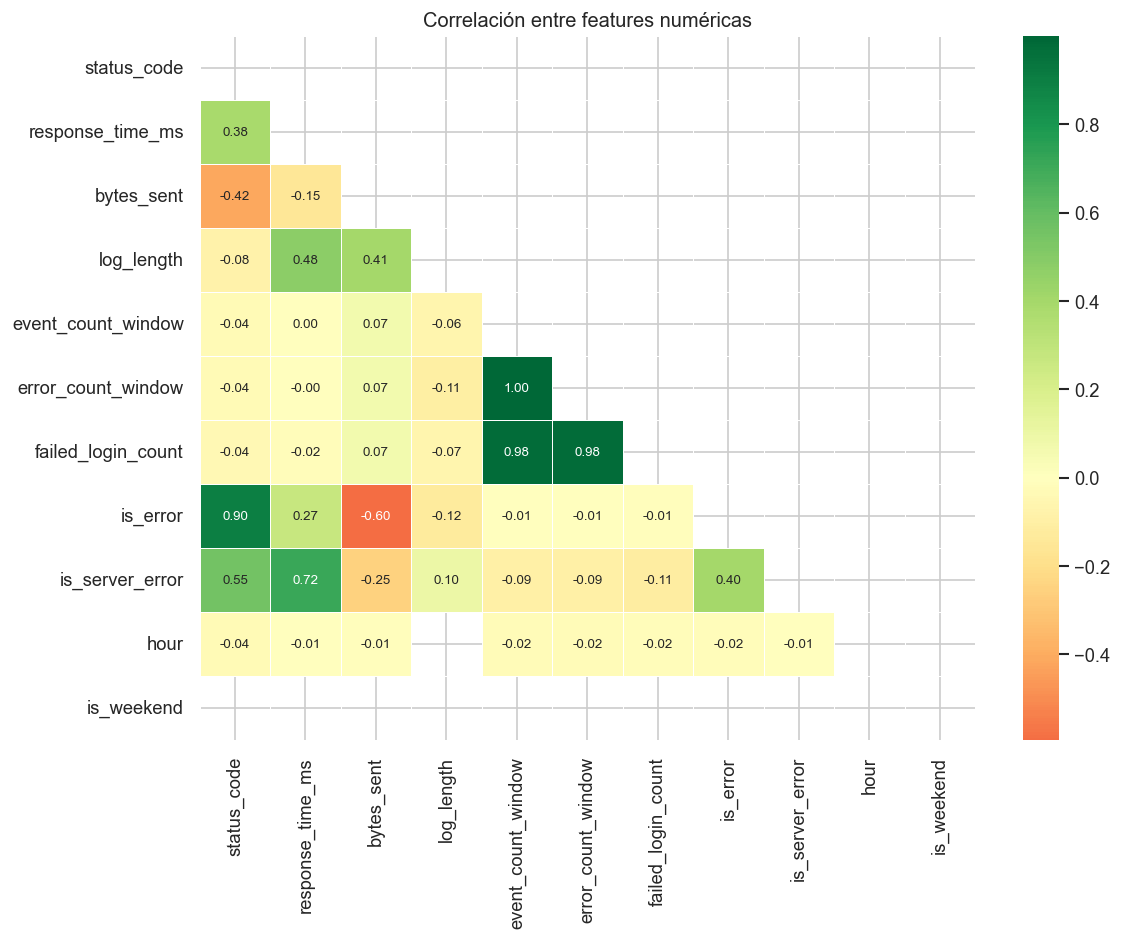

In [9]:
numeric_cols = [
    'status_code', 'response_time_ms', 'bytes_sent', 'log_length',
    'event_count_window', 'error_count_window', 'failed_login_count',
    'is_error', 'is_server_error', 'hour', 'is_weekend'
]
available = [c for c in numeric_cols if c in df.columns]

corr = df[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.5, annot_kws={'size': 8}
)
ax.set_title('Correlación entre features numéricas')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Observaciones clave

Completar con los hallazgos reales una vez ejecutado con datos reales:

- **Desbalance de clases:** indicar ratio normal/anomalía
- **Escenario dominante:** cuál genera más eventos
- **Feature más discriminativa:** observar en heatmap
- **IP atacante:** confirmar que `203.0.113.99` concentra eventos anómalos
- **Response time:** los errores 500 tienen tiempos significativamente más altos

Estas observaciones justifican el uso de modelos no supervisados en el **Capítulo 4** de la tesis.